In [1]:
import numpy as np
import pandas as pd

In [2]:
#random seed
np.random.seed(42)

set1no = 900
set2no = 100

In [4]:
df1 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set1no),
    "feature_2": np.random.normal(loc=0, scale=1, size=set1no),
    "target" : [0] * set1no
})

df2 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set2no),
    "feature_2": np.random.normal(loc=0, scale=1, size=set2no),
    "target" : [1] * set2no
})

In [5]:
df1.head()

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0


In [6]:
df2.head()

,feature_1,feature_2,target
0,-1.388543,-0.556119,1
1,-1.600271,-0.130060,1
2,-1.217283,1.669070,1
3,0.159463,-0.942558,1
4,-0.892788,1.614779,1


In [7]:
df = pd.concat([df1, df2]).reset_index(drop=True)

In [8]:
df


,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
995,1.001632,0.028458,1
996,1.393455,-2.077812,1
997,0.710549,-0.320298,1
998,0.429341,1.643378,1


In [9]:
df["target"].unique()

array([0, 1])

In [10]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [12]:
#upsampling -> upsample minority -- azınlığı arttırmak
#downsampling -> downsample majority -- çoğunluğu azaltmak

In [13]:
#upsampling

In [14]:
df_minority = df[df["target"] == 1]
df_minority

,feature_1,feature_2,target
900,-1.388543,-0.556119,1
901,-1.600271,-0.130060,1
902,-1.217283,1.669070,1
903,0.159463,-0.942558,1
904,-0.892788,1.614779,1
...,...,...,...
995,1.001632,0.028458,1
996,1.393455,-2.077812,1
997,0.710549,-0.320298,1
998,0.429341,1.643378,1


In [15]:
df_majority = df[df["target"] == 0]
df_majority

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
895,3.926238,-0.325611,0
896,-2.084113,-0.164335,0
897,1.724697,0.212093,0
898,-0.287448,-0.993359,0


In [16]:
from sklearn.utils import resample

In [17]:
df_minority_upsampled = resample(df_minority,replace=True,n_samples=len(df_majority),random_state=42)

In [18]:
df_minority_upsampled.shape

(900, 3)

In [19]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,0.493655,-0.834282,1
992,-0.799941,-1.975488,1
914,-1.264498,-1.499016,1
971,0.157761,-1.102270,1
960,-0.451949,-0.731632,1


In [20]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [21]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [22]:
df_majority_downsampled = resample(df_majority,replace=True,n_samples=len(df_minority),random_state=42)

In [23]:
df_majority_downsampled["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [25]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [26]:
df_downsampled["target"].value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [29]:
#SMOTE = (Synthetic Minority Over-sampling Technique)
#benzer datalar oluşturarak azınlığıı çoğaltma

In [30]:
df

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
995,1.001632,0.028458,1
996,1.393455,-2.077812,1
997,0.710549,-0.320298,1
998,0.429341,1.643378,1


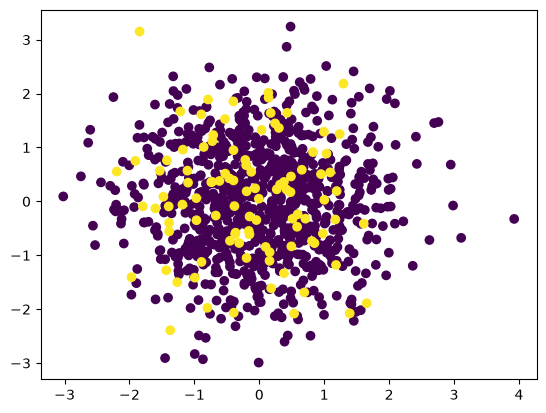

In [32]:
import matplotlib.pyplot as plt
plt.scatter(df["feature_1"],df["feature_2"], c = df["target"])

In [34]:
#imblearn

In [35]:
from imblearn.over_sampling import SMOTE

In [36]:
oversample = SMOTE()

In [37]:
(X, y) = oversample.fit_resample(df[["feature_1","feature_2"]],df["target"])

In [38]:
X

,feature_1,feature_2
0,-0.675178,-0.045512
1,-0.144519,-0.424236
2,-0.792420,-0.569833
3,-0.307962,0.329509
4,-1.893615,-1.517174
...,...,...
1795,-0.319929,-0.746879
1796,0.794455,0.849616
1797,0.225699,1.529741
1798,0.161328,1.764309


In [39]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 1800, dtype: int64

In [40]:
type(X)

pandas.DataFrame

In [41]:
oversample_df = pd.concat([X,y],axis=1)

In [45]:
oversample_df["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

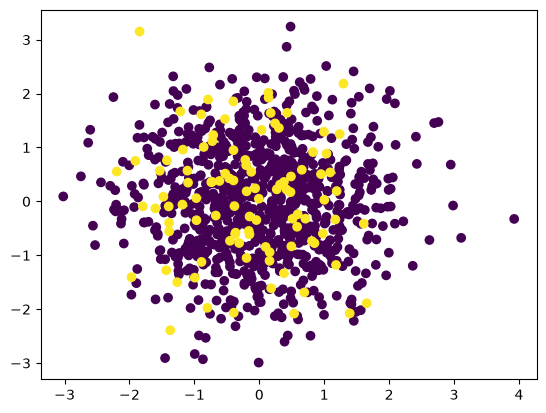

In [46]:
plt.scatter(df["feature_1"],df["feature_2"], c = df["target"])


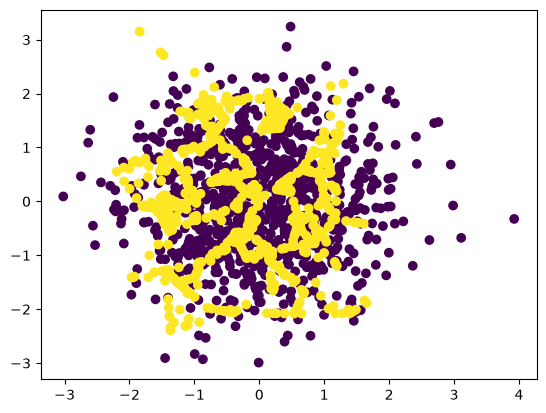

In [47]:
plt.scatter(oversample_df["feature_1"],oversample_df["feature_2"], c = oversample_df["target"])
